# Student Performance Analysis

## Project objective

This project investigates which demographic, behavioral, and academic factors
are associated with students' final exam scores.

## Research questions

1. Which variables have the strongest relationship with final exam score?
2. Does previous academic performance help predict the final exam score?
3. Are study time and attendance associated with better results?
4. How accurately can regression models predict a student's final exam score?

## Target variable

The target variable is `final_exam_score`, a continuous numerical score.

## Dataset

The dataset contains 1,000 student observations and 12 variables describing
study habits, attendance, parental education, previous grades, and final
academic performance.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import (train_test_split, KFold, cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
DATA_PATH = "../student_performance_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
range_checks = pd.DataFrame({
    "check": [
        "attendance between 0 and 100",
        "final score between 0 and 100",
        "previous grade between 0 and 100",
        "study time positive",
        "sleep hours positive"
    ],
    "passed": [
        df["attendance_percent"].between(0, 100).all(),
        df["final_exam_score"].between(0, 100).all(),
        df["previous_grade"].between(0, 100).all(),
        (df["study_time_hours"] > 0).all(),
        (df["sleep_hours"] > 0).all()
    ]
})

range_checks

,check,passed
0,attendance between 0 and 100,True
1,final score between 0 and 100,True
2,previous grade between 0 and 100,True
3,study time positive,True
4,sleep hours positive,True


All numerical variables fall within plausible ranges. No invalid values were detected in the main continuous features.

In [5]:
data_info = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique()
}).sort_values("missing_percent", ascending=False)

data_info

,dtype,missing_count,missing_percent,unique_values
parental_education,str,102,10.2,4
student_id,int64,0,0.0,1000
gender,str,0,0.0,2
study_time_hours,float64,0,0.0,70
attendance_percent,float64,0,0.0,327
sleep_hours,float64,0,0.0,65
internet_access,str,0,0.0,2
extracurricular_activities,str,0,0.0,2
part_time_job,str,0,0.0,2
previous_grade,float64,0,0.0,434


The only missing values occur in parental_education (10.2%). They will be handled inside the modelling pipeline to prevent data leakage.

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate student IDs: {df['student_id'].duplicated().sum():,}")

Rows: 1,000
Columns: 12
Duplicate rows: 0
Duplicate student IDs: 0


The dataset contains 1,000 rows and 12 columns. No duplicate rows or duplicate student IDs were found.

In [7]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']

Categorical columns:
['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']


In [8]:
for column in categorical_columns:
    print(f"{column}: {df[column].dropna().unique().tolist()}")

gender: ['Male', 'Female']
parental_education: ['Bachelors', 'High School', 'Masters', 'PhD']
internet_access: ['Yes', 'No']
extracurricular_activities: ['Yes', 'No']
part_time_job: ['No', 'Yes']
final_grade: ['A', 'B', 'D', 'C', 'F']


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,1000.0,500.5000,288.819436,1.0,250.750,500.5,750.250,1000.0
study_time_hours,1000.0,3.5707,1.478559,0.5,2.600,3.6,4.500,8.1
attendance_percent,1000.0,85.0923,9.270685,54.8,78.800,85.2,91.900,100.0
sleep_hours,1000.0,6.7995,1.203527,3.2,5.900,6.8,7.600,10.0
previous_grade,1000.0,69.7409,12.613425,31.3,61.000,69.6,78.400,100.0
final_exam_score,1000.0,83.5435,10.341333,46.8,76.075,83.8,91.525,100.0


1. The average attendance rate is approximately 85%.
2. The average final exam score is approximately 83.5 points.
3. Previous grades (previous_grade) show considerable variability across students.
4. Final exam scores range from 46.8 to 100 points.

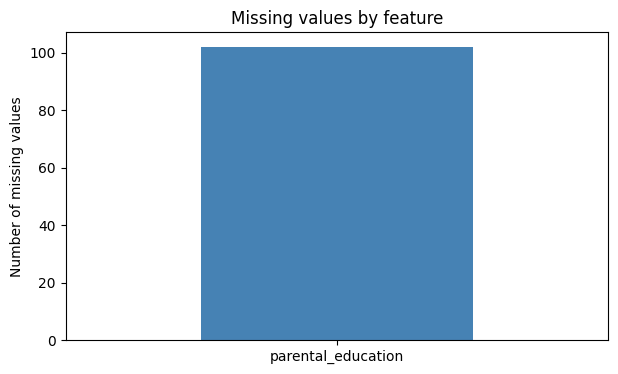

In [11]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda x: x > 0]
)

missing.plot(kind="bar", figsize=(7, 4), color="steelblue")
plt.title("Missing values by feature")
plt.ylabel("Number of missing values")
plt.xticks(rotation=0)
plt.show()

The dataset does not explain why parental education values are missing, so treating missingness as an Unknown category is a modeling choice rather than a confirmed real-world category.

In [12]:
category_summary = []

for column in categorical_columns:
    counts = df[column].value_counts(dropna=False)

    for category, count in counts.items():
        category_summary.append({
            "Feature": column,
            "Category": category,
            "Count": count,
            "Percent": count / len(df) * 100
        })

category_summary = pd.DataFrame(category_summary)
category_summary.round(1)

,Feature,Category,Count,Percent
0,gender,Female,510,51.0
1,gender,Male,490,49.0
2,parental_education,High School,356,35.6
3,parental_education,Bachelors,308,30.8
4,parental_education,Masters,184,18.4
5,parental_education,NaN,102,10.2
6,parental_education,PhD,50,5.0
7,internet_access,Yes,854,85.4
8,internet_access,No,146,14.6
9,extracurricular_activities,Yes,572,57.2


`final_grade` is imbalanced, especially for class F. Since this notebook focuses on regression for `final_exam_score`, classification analysis is left for a separate project.

## Initial data quality findings

- The dataset contains 1,000 rows and 12 columns.
- `student_id` is a unique identifier and should not be used as a predictive feature.
- Most columns have appropriate data types.
- `parental_education` contains 102 missing values, corresponding to 10.2% of the dataset.
- No fully duplicated rows were found.
- The target variable `final_grade` contains five classes.
- Grade classes are imbalanced, with only 12 observations in class F.

In [13]:
df.groupby(
    df["parental_education"].isna()
)["final_exam_score"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
parental_education,,,,
False,898,83.555791,83.8,10.345629
True,102,83.435294,82.3,10.353721


In [14]:
df_clean = df.copy()

In [15]:
df_clean["parental_education"] = (
    df_clean["parental_education"]
    .fillna("Unknown")
)

In [16]:
df_clean["parental_education"].value_counts(
    dropna=False
)

parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64

In [17]:
known_education = df.loc[
    df["parental_education"].notna(),
    "final_exam_score"
]

missing_education = df.loc[
    df["parental_education"].isna(),
    "final_exam_score"
]

t_stat, p_value = ttest_ind(
    known_education,
    missing_education,
    equal_var=False
)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.1114
p-value: 0.9115


In [18]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: the group means differ statistically.")
else:
    print("Fail to reject H0: there is insufficient evidence of a difference.")

Fail to reject H0: there is insufficient evidence of a difference.


In [19]:
mean_diff = known_education.mean() - missing_education.mean()

pooled_std = np.sqrt(
    (
        (len(known_education) - 1) * known_education.var(ddof=1)
        + (len(missing_education) - 1) * missing_education.var(ddof=1)
    )
    /
    (len(known_education) + len(missing_education) - 2)
)

cohens_d = mean_diff / pooled_std

print(f"Mean difference: {mean_diff:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")

Mean difference: 0.1205
Cohen's d: 0.0116


Missing values were retained as a separate Unknown category because the absence of parental education information may itself carry information, and no statistically significant difference in final exam scores was detected between students with and without missing values.

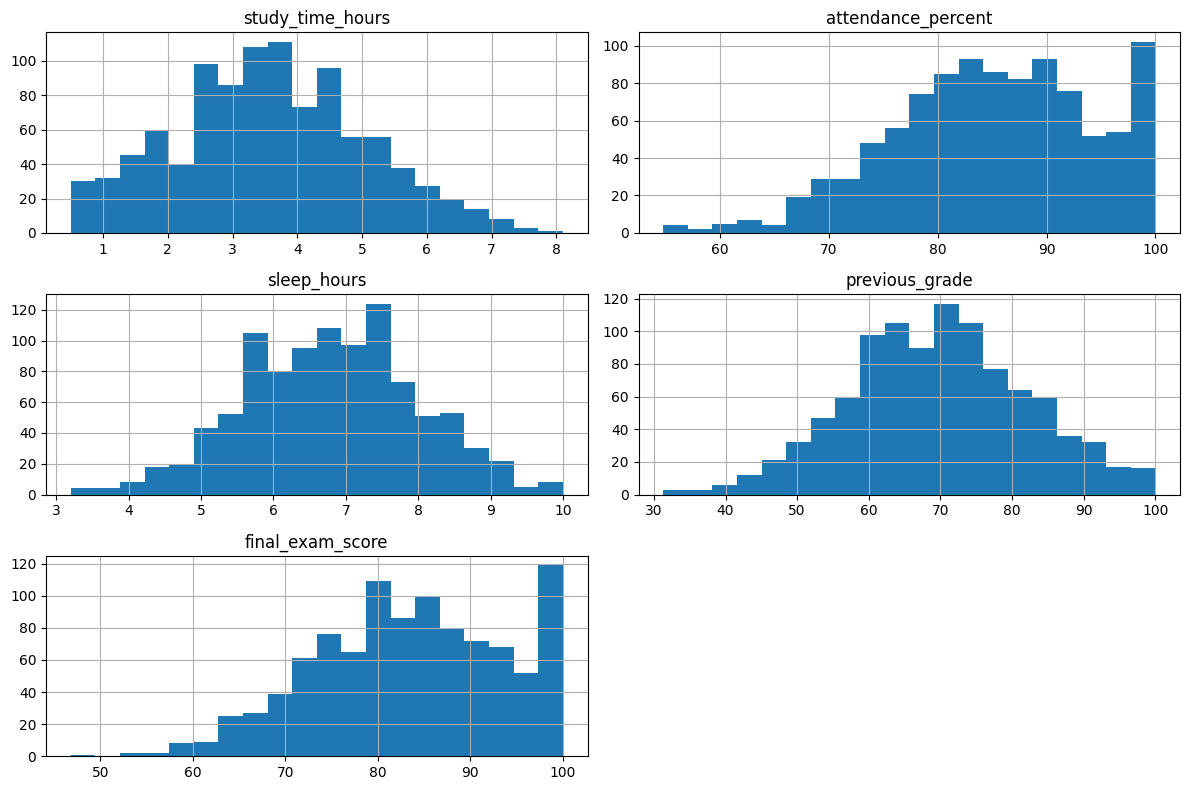

In [20]:
numeric_columns = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade",
    "final_exam_score"
]

df_clean[numeric_columns].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

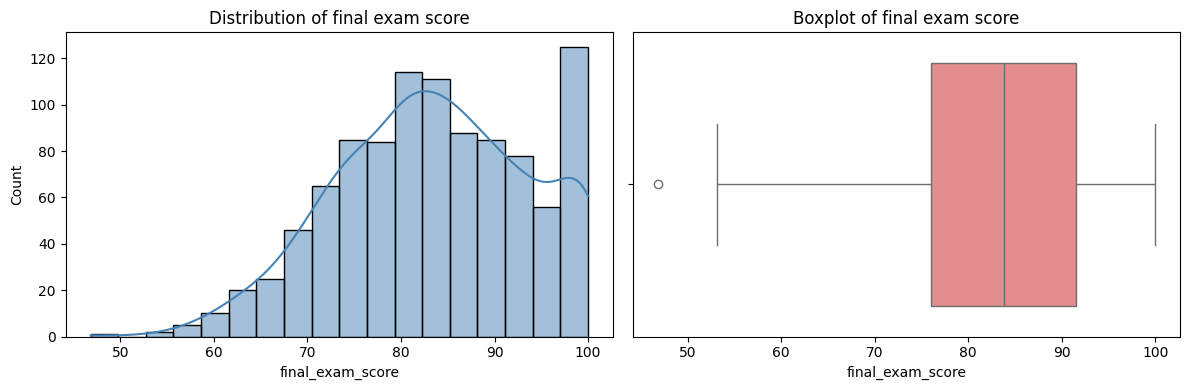

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df_clean,
    x="final_exam_score",
    kde=True,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Distribution of final exam score")

sns.boxplot(
    data=df_clean,
    x="final_exam_score",
    ax=axes[1],
    color="lightcoral"
)
axes[1].set_title("Boxplot of final exam score")

plt.tight_layout()
plt.show()

## Distribution of Final Exam Scores

1. The distribution is negatively (left) skewed: most students received relatively high scores, while the distribution has a longer tail toward lower scores.
2. There are no substantial extreme outliers, although the boxplot indicates one potential low-end outlier.
3. The scores have an upper boundary of 100, and there is a noticeable accumulation of observations at this maximum value, which may indicate an association.
4. Most exam scores are concentrated approximately between 75 and 95, with a median of around 84.
5. Overall, students tend to achieve relatively high final exam scores.

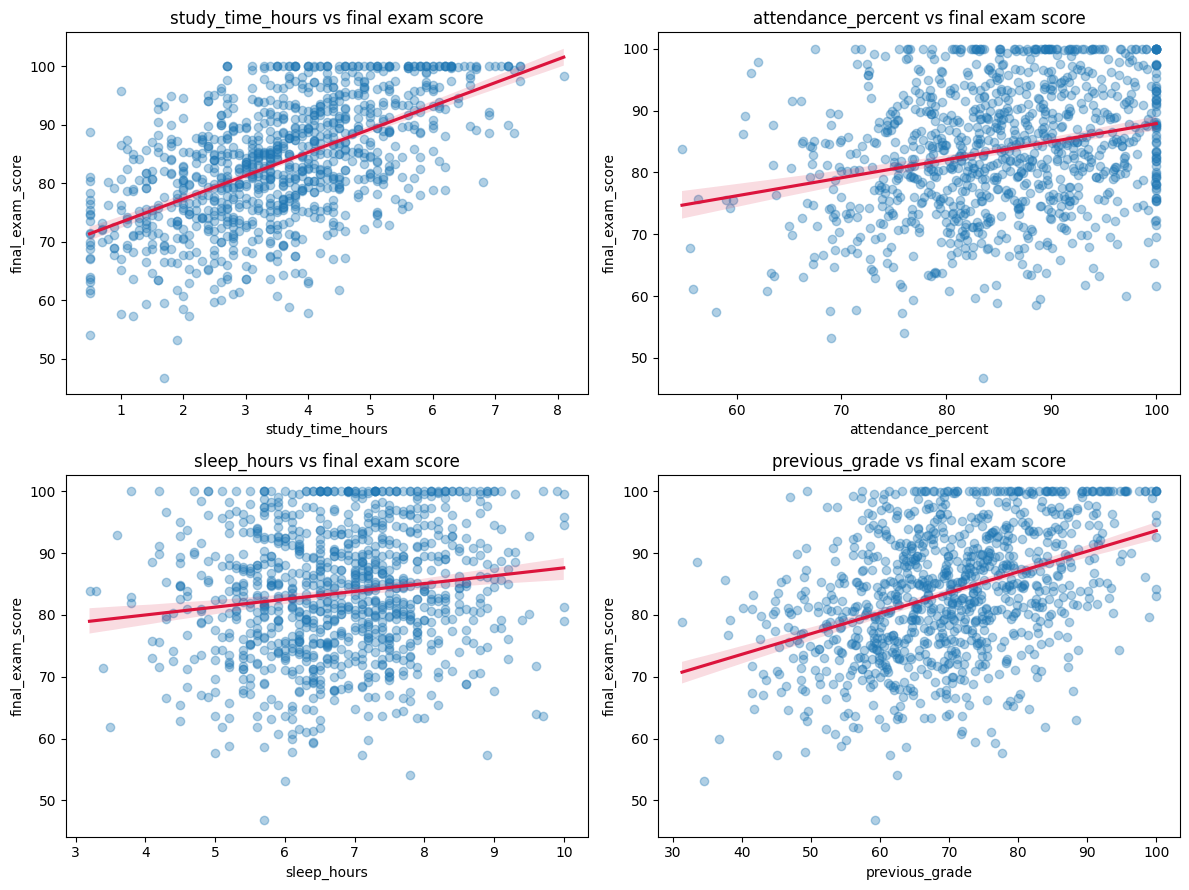

In [22]:
numeric_predictors = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.ravel(), numeric_predictors):
    sns.regplot(
        data=df_clean,
        x=feature,
        y="final_exam_score",
        scatter_kws={"alpha": 0.35},
        line_kws={"color": "crimson"},
        ax=ax
    )
    ax.set_title(f"{feature} vs final exam score")

plt.tight_layout()
plt.show()

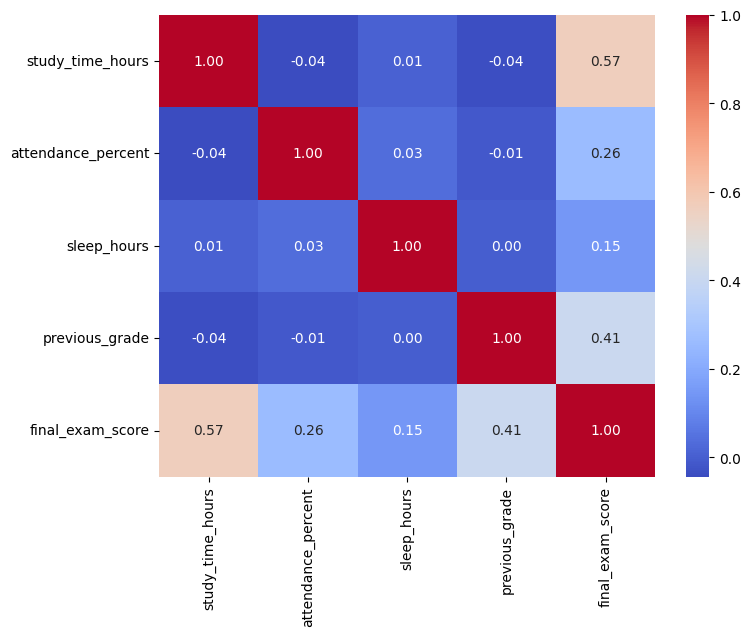

In [23]:
corr = df_clean[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

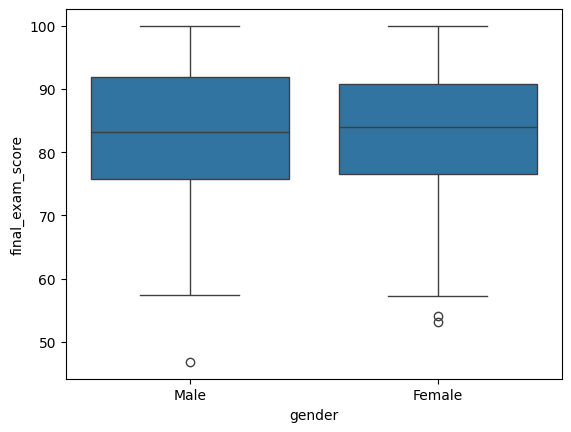

In [24]:
sns.boxplot(
    x="gender",
    y="final_exam_score",
    data=df_clean
)

plt.show()

There was no statistically significant difference in the mean final exam scores between male and female students.

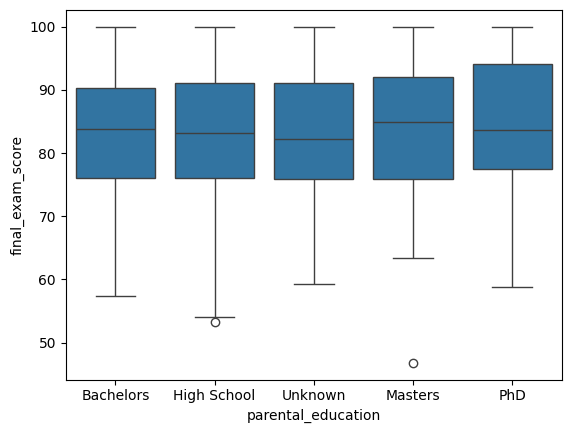

In [25]:
sns.boxplot(
    x="parental_education",
    y="final_exam_score",
    data=df_clean
)

plt.show()

There was no statistically significant difference in the mean final exam scores across parental education groups

<Axes: xlabel='part_time_job', ylabel='final_exam_score'>

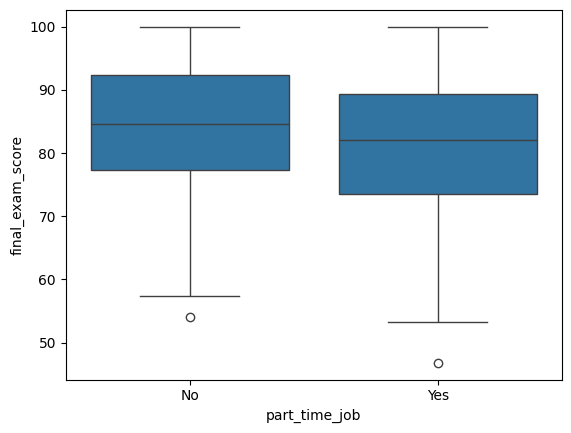

In [26]:
sns.boxplot(
    x="part_time_job",
    y="final_exam_score",
    data=df_clean
)


Students with part-time jobs had lower average scores in this dataset. This is an association and does not establish that part-time employment causes lower performance.

The dataset contains no duplicate observations and only one feature with missing values (parental_education), which was encoded as a separate Unknown category.
Most numerical variables exhibit approximately unimodal distributions. study_time_hours shows slight right skewness.
final_exam_score is positively correlated with study_time_hours (r = 0.57), previous_grade (r = 0.41), and attendance_percent (r = 0.26).
No substantial difference in final exam scores was observed between male and female students.
Students without a part-time job tend to achieve slightly higher scores, although this observation should be verified statistically.
Based on the exploratory analysis, study_time_hours, previous_grade, and attendance_percent appear to be the most promising predictors of exam performance.

In [27]:
target = "final_exam_score"

X = df_clean.drop(columns=[target, "final_grade", "student_id"])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")


Training observations: 800
Test observations: 200


final_grade is excluded because it is directly derived from the final exam score and would cause target leakage.

In [28]:
numeric_features = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade"
]

categorical_features = [
    "gender",
    "parental_education",
    "internet_access",
    "extracurricular_activities",
    "part_time_job"
]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [29]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [31]:
y_pred = lr_pipeline.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("On train dataset")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

On train dataset
MAE: 4.98
RMSE: 6.42
R²: 0.617


In [ ]:
preprocessor = lr_pipeline.named_steps["preprocessor"]
regressor = lr_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
coefficients_values = regressor.coef_

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients_values
})


coefficients["AbsoluteCoefficient"] = (
    coefficients["Coefficient"].abs()
)

top_coefficients = (
    coefficients
    .sort_values(
        by="AbsoluteCoefficient",
        ascending=False
    )
    .drop(columns="AbsoluteCoefficient")
)

top_coefficients["Feature"] = (
    top_coefficients["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_coefficients

,Feature,Coefficient
0,study_time_hours,6.040392
9,internet_access_Yes,5.996838
3,previous_grade,4.377974
11,part_time_job_Yes,-3.587613
1,attendance_percent,3.142902
2,sleep_hours,1.196368
7,parental_education_PhD,1.067565
10,extracurricular_activities_Yes,0.837573
6,parental_education_Masters,0.808378
8,parental_education_Unknown,-0.542553


Because numerical features are standardized, their coefficients should be compared as relative associations rather than as raw score changes per original unit.

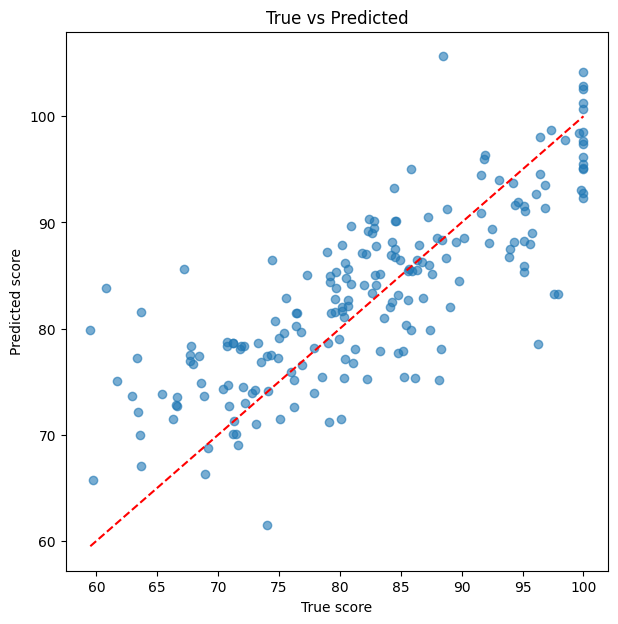

In [47]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("True score")
plt.ylabel("Predicted score")

plt.title("True vs Predicted")

plt.show()

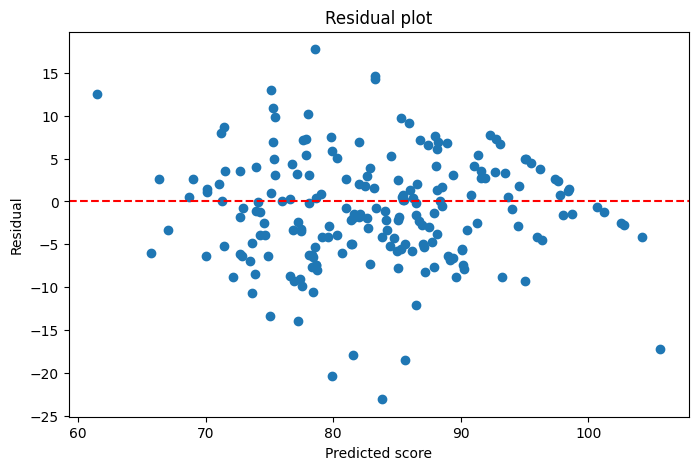

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted score")
plt.ylabel("Residual")

plt.title("Residual plot")

plt.show()

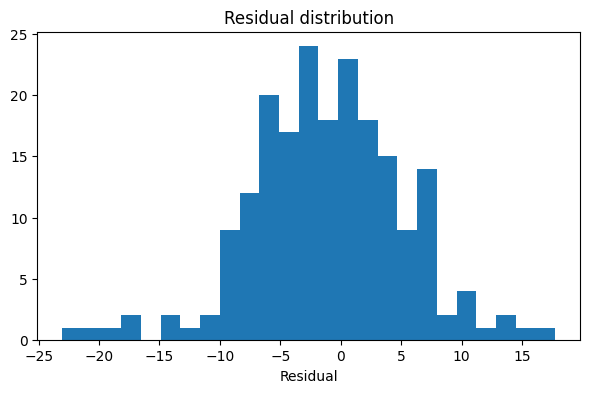

In [47]:
plt.figure(figsize=(7,4))

plt.hist(
    residuals,
    bins=25
)

plt.xlabel("Residual")

plt.title("Residual distribution")

plt.show()

Model Evaluation
The linear regression model captures a clear linear relationship between predictors and the target.
Residuals are randomly distributed around zero without obvious systematic patterns.
The residual distribution is approximately symmetric and close to normal.
The model tends to underestimate the highest-performing students and overestimate the lowest-performing students, indicating regression toward the mean.
An R² of approximately 0.62 suggests that the model explains a substantial portion of the variance, but additional nonlinear relationships or unobserved variables may still contribute to prediction errors.

In [ ]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
for depth in depths:

    dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            random_state=42
        ))
    ]
)

    dt_pipeline.fit(X_train, y_train)

    print("max depth = ", depth)

    tree_pred = dt_pipeline.predict(X_test)

    mae = mean_absolute_error(
    y_test,
    tree_pred
)

    rmse = mean_squared_error(
    y_test,
    tree_pred
) ** 0.5

    r2 = r2_score(
    y_test,
    tree_pred
)

    print(f"mae = ", mae)
    print("rmse = ", rmse)
    print("r2 = ", r2)

    train_pred = dt_pipeline.predict(X_train)

    print("train: ",
    r2_score(
        y_train,
        train_pred
    )
)

    print("test: ",
    r2_score(
        y_test,
        tree_pred
    )
)

max depth =  1
mae =  7.84051197823801
rmse =  9.549070161379948
r2 =  0.15284914351867362
train:  0.2333064132529341
test:  0.15284914351867362
max depth =  2
mae =  7.010139788874351
rmse =  8.701151522742862
r2 =  0.29661670671168305
train:  0.35315312904660934
test:  0.29661670671168305
max depth =  3
mae =  6.525363955576224
rmse =  8.215634841414527
r2 =  0.3729230437352795
train:  0.4481527548202956
test:  0.3729230437352795
max depth =  4
mae =  6.248360640062453
rmse =  7.88048429753713
r2 =  0.42304173155870084
train:  0.5363542737201012
test:  0.42304173155870084
max depth =  5
mae =  5.981126665884417
rmse =  7.626085894231522
r2 =  0.45969128743610366
train:  0.6181407270386796
test:  0.45969128743610366
max depth =  6
mae =  6.12404888206456
rmse =  8.044801470735788
r2 =  0.39873039840209823
train:  0.6977716991176623
test:  0.39873039840209823
max depth =  8
mae =  6.759833430742317
rmse =  8.928190949735662
r2 =  0.25943100491483584
train:  0.8484068191060726
test:  0.

The best balance of model performance is achieved with a tree depth of 5.

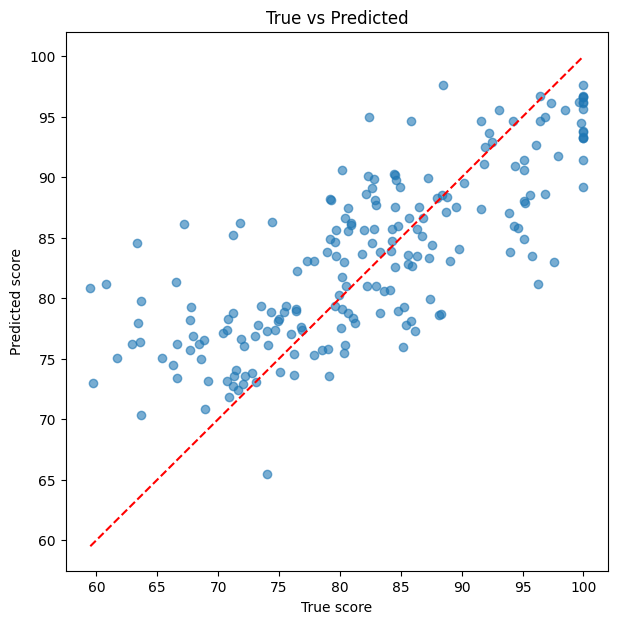

In [73]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("True score")
plt.ylabel("Predicted score")

plt.title("True vs Predicted")

plt.show()

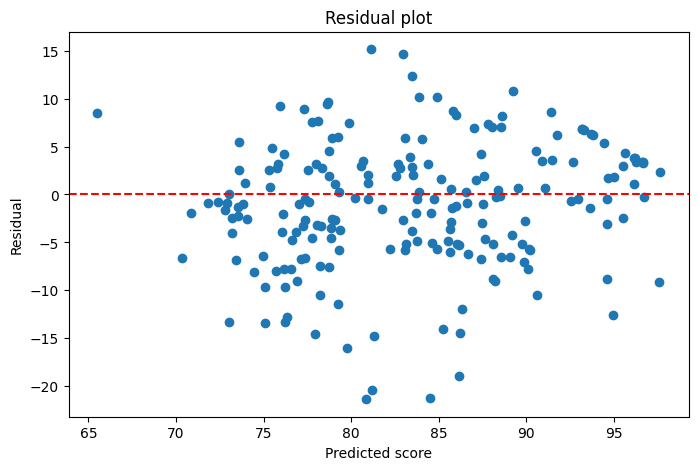

In [74]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted score")
plt.ylabel("Residual")

plt.title("Residual plot")

plt.show()

In [32]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model_rf", RandomForestRegressor(
            random_state=42,
            max_depth=5,
            n_estimators=500,
            bootstrap=True
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("On train dataset")
print(f"mae = ", mae)
print("rmse = ", rmse)
print("r2 = ", r2)

train_pred = rf_pipeline.predict(X_train)

print("train: ",
    r2_score(
        y_train,
        train_pred
    )
)

print("test: ",
    r2_score(
        y_test,
        y_pred
    )
)

On train dataset
mae =  5.29329553724597
rmse =  6.794119668254459
r2 =  0.5711504391105658
train:  0.7010427918828508
test:  0.5711504391105658


In [72]:
preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model_rf"]

feature_names = preprocessor.get_feature_names_out()
importance_values = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance

,Feature,Importance
0,study_time_hours,0.499513
1,previous_grade,0.291209
2,attendance_percent,0.137901
3,sleep_hours,0.025199
4,internet_access_Yes,0.022332
5,part_time_job_Yes,0.017081
6,parental_education_High School,0.001832
7,extracurricular_activities_Yes,0.001411
8,gender_Male,0.001262
9,parental_education_Masters,0.000783


Random Forest feature importance is based on the average reduction in impurity across the trees. It is useful for exploratory interpretation but should not be interpreted as a causal effect.

In [ ]:
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

In [69]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

comparison_results = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    comparison_results.append({
        "Model": model_name,
        "Mean R²": scores["test_r2"].mean(),
        "Std R²": scores["test_r2"].std(),
        "Mean MAE": -scores["test_mae"].mean(),
        "Mean RMSE": -scores["test_rmse"].mean()
    })

comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values(
        by="Mean R²",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_df.round(3)

,Model,Mean R²,Std R²,Mean MAE,Mean RMSE
0,Linear Regression,0.654,0.04,4.797,5.998
1,Random Forest,0.544,0.05,5.521,6.891
2,Decision Tree,0.375,0.06,6.401,8.069


Three regression models were evaluated using 5-fold cross-validation. Linear Regression achieved the highest mean R² (0.650 ± 0.035), outperforming both Random Forest (0.562 ± 0.044) and Decision Tree (0.429 ± 0.049). The lower standard deviation additionally indicates that Linear Regression provides the most stable performance across different data splits. In this dataset and under the selected preprocessing and hyperparameters, Linear Regression achieved the best cross-validation performance. This suggests that a linear model is a strong baseline here, but it does not prove that the underlying relationships are purely linear.

In [70]:
results = X_test.copy()

results["true_score"] = y_test.values
results["predicted_score"] = y_pred

results["error"] = (
    results["true_score"]
    - results["predicted_score"]
)

results["abs_error"] = (
    abs(results["error"])
)

results.head(10)

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,true_score,predicted_score,error,abs_error
521,Male,4.6,73.7,5.4,PhD,No,Yes,Yes,74.8,71.8,86.226535,-14.426535,14.426535
737,Male,1.8,82.4,6.4,High School,Yes,No,Yes,70.9,66.6,76.216678,-9.616678,9.616678
740,Male,4.0,73.2,4.5,High School,Yes,No,No,49.4,62.9,76.235899,-13.335899,13.335899
660,Female,4.5,85.0,8.2,Bachelors,Yes,No,No,71.9,95.2,87.846190,7.353810,7.353810
411,Female,4.5,77.0,4.7,High School,Yes,No,No,81.6,90.2,89.517396,0.682604,0.682604
678,Female,3.0,87.7,5.0,Unknown,No,No,No,54.8,63.6,76.354373,-12.754373,12.754373
626,Male,6.6,77.3,5.3,High School,No,Yes,No,84.0,96.8,94.999044,1.800956,1.800956
513,Female,2.3,82.0,7.1,High School,Yes,Yes,No,51.7,77.9,75.320621,2.579379,2.579379
859,Male,1.7,86.0,7.7,High School,No,No,Yes,80.0,66.5,81.311701,-14.811701,14.811701
136,Male,2.5,82.7,7.2,High School,No,No,Yes,55.0,59.7,73.029288,-13.329288,13.329288


In [182]:
results.groupby(
    "part_time_job"
)["abs_error"].mean()

part_time_job
No     5.404858
Yes    6.184540
Name: abs_error, dtype: float64

In [183]:
results.groupby(
    "gender"
)["abs_error"].mean()

gender
Female    5.434950
Male      5.814787
Name: abs_error, dtype: float64

In [184]:
results.groupby(
    "internet_access"
)["abs_error"].mean()

internet_access
No     6.818516
Yes    5.377625
Name: abs_error, dtype: float64

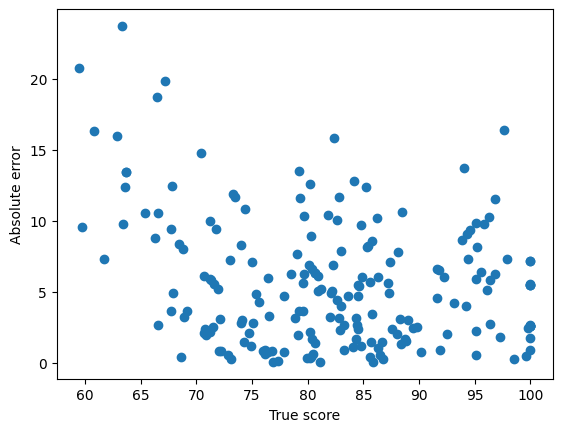

In [ ]:
plt.scatter(
    results["true_score"],
    results["abs_error"]
)

plt.xlabel("True score")
plt.ylabel("Absolute error")

plt.show()

In [186]:
results["grade_group"] = pd.cut(
    results["previous_grade"],
    bins=[0,60,75,90,100],
    labels=["Low","Medium","High","Very High"]
)

results.groupby("grade_group")["abs_error"].mean()

grade_group
Low          4.753319
Medium       5.745869
High         6.052763
Very High    5.742112
Name: abs_error, dtype: float64

Conclusion

We investigated the impact of various behavioral, academic, and demographic factors on students' academic performance. Among the evaluated models, Linear Regression achieved the best predictive performance, suggesting that the relationships between the available predictors and final exam scores are predominantly linear. Consequently, more flexible non-linear models, such as Decision Tree and Random Forest regressors, did not provide an improvement in predictive performance.

Across the evaluated models, three features consistently emerged as the strongest predictors of final exam performance: study time (study_time_hours), previous academic performance (previous_grade), and attendance (attendance_percent). The Linear Regression model also identified internet access as being strongly associated with final exam scores.

One of the main limitations of this analysis is the relatively small dataset (1,000 observations), which may limit the models' ability to learn more complex patterns and reduce the generalizability of the results. A larger and more diverse dataset could provide more reliable estimates and potentially improve predictive performance.

## Key findings

1. Study time and previous grade were the strongest predictors of final exam
   score.
2. Attendance was positively associated with final exam performance.
3. Linear Regression achieved the best predictive performance, suggesting that the relationships between the available predictors and final exam scores are predominantly linear.
4. The model provided useful but incomplete predictions, indicating that other
   relevant factors are not included in the dataset.

## Limitations

- The data are observational, so the analysis does not establish causality.
- The reasons for missing parental education values are unknown.
- The dataset may not generalize to all students or educational settings.
- Model performance should be validated on an external dataset before practical
  use.

## Future work

- Compare Ridge and ElasticNet regression.
- Test a classification model for `final_grade`.
- Add external or longitudinal data.
- Evaluate permutation importance and model calibration.